This Document creates the counterexample. That being, showing how the naive estimator fails under exogenous dosing conditions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from simulation.pthyrosim_model import simulate_patient

In [35]:
# True example patient

true_patient = {
    "height": 173,  
    "weight": 70,   
    "sex": "male",
    "lt4": 65.5,
    "lt3": 10,
    "rtf": 0.75
}

df_true = simulate_patient(
    height=true_patient["height"],
    weight=true_patient["weight"],
    sex=true_patient["sex"],
    lt4_dose=true_patient["lt4"],
    lt3_dose=true_patient["lt3"],
    rtf=true_patient["rtf"]
)

# take a randomized clinical sample
tail = df_true.tail(50)

idx = np.random.randint(0, len(tail))
sample = tail.iloc[idx]

FT4_obs = sample["FT4"]
FT3_obs = sample["FT3"]
TSH_obs = sample["TSH"]

print("Observed (simulated) labs from treated patient:")
print(f"FT4: {FT4_obs:.4f}, FT3: {FT3_obs:.4f}, TSH: {TSH_obs:.4f}")

Observed (simulated) labs from treated patient:
FT4: 127.1708, FT3: 26.2403, TSH: 0.3789


In [36]:
# Naive model, no therapy

rtf_grid = np.linspace(0.0, 1.0, 101)

ft4_vals = []
ft3_vals = []
tsh_vals = []

for rtf in rtf_grid:
    df = simulate_patient(
        height=true_patient["height"],
        weight=true_patient["weight"],
        sex=true_patient["sex"],
        lt4_dose=0,   # <-- Naive assumption
        lt3_dose=0,
        rtf=rtf
    )

    tail = df.tail(50)

    ft4_vals.append(tail["FT4"].mean())
    ft3_vals.append(tail["FT3"].mean())
    tsh_vals.append(tail["TSH"].mean())


ft4_vals = np.array(ft4_vals)
ft3_vals = np.array(ft3_vals)
tsh_vals = np.array(tsh_vals)

In [37]:
# Naive inversion

def estimate_rtf_from_signal(signal_vals, rtf_grid, observed_value):
    idx = np.argmin(np.abs(signal_vals - observed_value))
    return rtf_grid[idx]

rtf_est_ft4 = estimate_rtf_from_signal(ft4_vals, rtf_grid, FT4_obs)
rtf_est_ft3 = estimate_rtf_from_signal(ft3_vals, rtf_grid, FT3_obs)
rtf_est_tsh = estimate_rtf_from_signal(tsh_vals, rtf_grid, TSH_obs)

print("\nTrue RTF:", true_patient["rtf"])
print("Naive estimated RTF (FT4):", rtf_est_ft4)
print("Naive estimated RTF (FT3):", rtf_est_ft3)
print("Naive estimated RTF (TSH):", rtf_est_tsh)


True RTF: 0.75
Naive estimated RTF (FT4): 1.0
Naive estimated RTF (FT3): 1.0
Naive estimated RTF (TSH): 0.0


In [38]:
# Monte Carlo 

def sample_observation(df, window=250):
    tail = df.tail(window)
    idx = np.random.randint(0, len(tail))
    return tail.iloc[idx][["FT4", "FT3", "TSH"]]

def estimate_rtf(a, b, c, d, e, f):
    idx = np.argmin((a - b)**2+(c - d)**2+(e - f)**2)
    return rtf_grid[idx]

n_trials = 10000
estimated_rtfs = []

ft4_vals = []
ft3_vals = []
tsh_vals = []

for rtf in rtf_grid:
    df = simulate_patient(
        height=true_patient["height"],
        weight=true_patient["weight"],
        sex=true_patient["sex"],
        lt4_dose=0,
        lt3_dose=0,
        rtf=rtf
    )

    tail = df.tail(250)

    ft4_vals.append(tail["FT4"].mean())
    ft3_vals.append(tail["FT3"].mean())
    tsh_vals.append(tail["TSH"].mean())

ft4_vals = np.array(ft4_vals)
ft3_vals = np.array(ft3_vals)
tsh_vals = np.array(tsh_vals)

for i in range(n_trials):
    obs = sample_observation(df_true)

    est_rtf = estimate_rtf(
        ft4_vals, obs["FT4"],
        ft3_vals, obs["FT3"],
        tsh_vals, obs["TSH"]
    )

    estimated_rtfs.append(est_rtf)

    if ((i+1) % 1000 == 0):
        print("Completed", i+1, "iterations.")

Completed 1000 iterations.
Completed 2000 iterations.
Completed 3000 iterations.
Completed 4000 iterations.
Completed 5000 iterations.
Completed 6000 iterations.
Completed 7000 iterations.
Completed 8000 iterations.
Completed 9000 iterations.
Completed 10000 iterations.


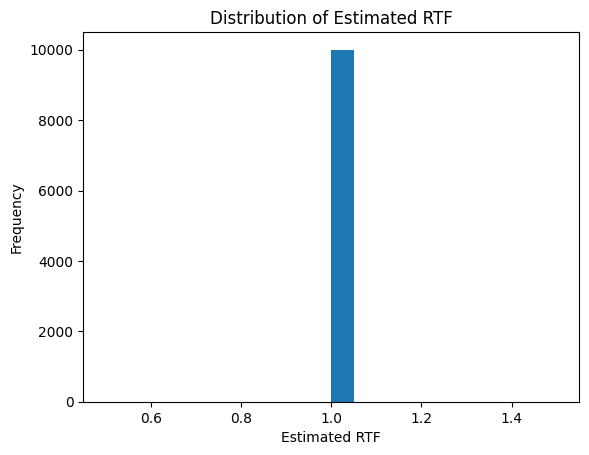

In [39]:
plt.hist(estimated_rtfs, bins=20)
plt.title("Distribution of Estimated RTF")
plt.xlabel("Estimated RTF")
plt.ylabel("Frequency")

plt.show()